In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/DataCoSupplyChainDataset.csv', encoding='latin1')
print(df.shape)
df.head()

ModuleNotFoundError: No module named 'pandas'

In [3]:
import sys
print(sys.executable)

/opt/homebrew/opt/python@3.11/bin/python3.11


In [4]:
!pip install pandas matplotlib seaborn

In [5]:
import sys
!{sys.executable} -m pip install pandas matplotlib seaborn

  Using cached pandas-3.0.3-cp311-cp311-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached numpy-2.4.6-cp311-cp311-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached contourpy-1.3.3-cp311-cp311-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp311-cp311-macosx_10_9_universal2.whl.metadata (118 kB)
  Using cached kiwisolver-1.5.0-cp311-cp311-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pillow-12.3.0-cp311-cp311-macosx_11_0_arm64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached pandas-3.0.3-cp311-cp311-macosx_11_0_arm64.whl (9.9 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 1.9 MB/s  0:00:051.8 MB/s eta 0:00:01:01
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.3-cp311-cp311-macosx_11_0_arm64.whl (270 kB)
Using cached cycler

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/DataCoSupplyChainDataset.csv', encoding='latin1')
print(df.shape)
df.head()

(180519, 53)


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [7]:
df['order_date'] = pd.to_datetime(df['order date (DateOrders)'])
df = df.dropna(subset=['order_date'])
print(df['order_date'].min(), 'to', df['order_date'].max())
print(df['Category Name'].nunique(), 'categories')

2015-01-01 00:00:00 to 2018-01-31 23:38:00
50 categories


In [8]:
top_categories = df['Category Name'].value_counts().head(10)
print(top_categories)

Category Name
Cleats                  24551
Men's Footwear          22246
Women's Apparel         21035
Indoor/Outdoor Games    19298
Fishing                 17325
Water Sports            15540
Camping & Hiking        13729
Cardio Equipment        12487
Shop By Sport           10984
Electronics              3156
Name: count, dtype: int64


In [9]:
daily = (
    df.groupby(['Category Name', pd.Grouper(key='order_date', freq='D')])
      .agg(
          quantity=('Order Item Quantity', 'sum'),
          sales=('Sales', 'sum'),
          avg_discount_rate=('Order Item Discount Rate', 'mean'),
          late_delivery_risk=('Late_delivery_risk', 'mean')
      )
      .reset_index()
)
print(daily.shape)
daily.head()

(17151, 6)


,Category Name,order_date,quantity,sales,avg_discount_rate,late_delivery_risk
0,Accessories,2015-01-01,11,274.889999,0.1625,0.75
1,Accessories,2015-01-02,5,124.949997,0.2500,1.00
2,Accessories,2015-01-03,3,74.970001,0.1800,0.00
3,Accessories,2015-01-05,5,124.950001,0.1600,1.00
4,Accessories,2015-01-07,4,99.960001,0.1100,1.00


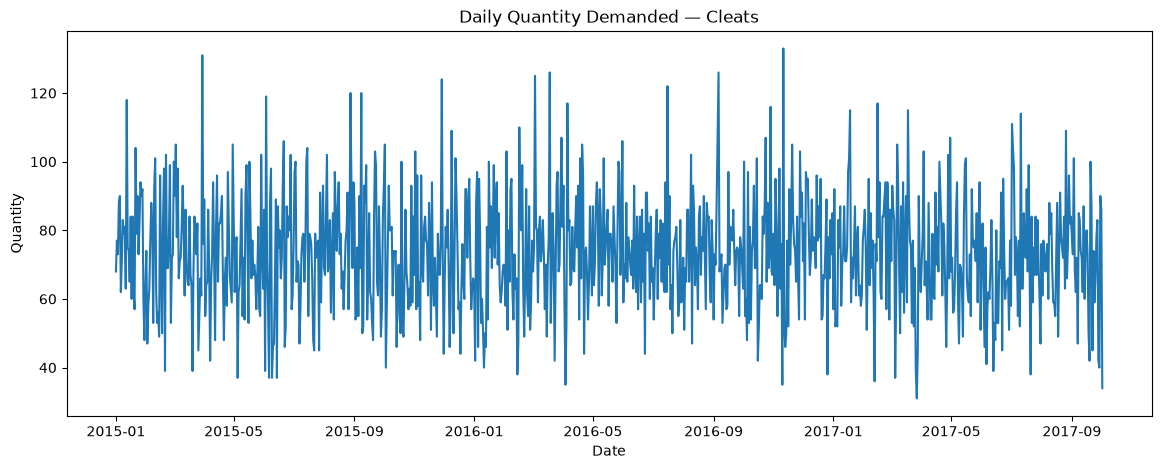

In [10]:
top_cat = top_categories.index[0]
sample = daily[daily['Category Name'] == top_cat]

plt.figure(figsize=(14,5))
plt.plot(sample['order_date'], sample['quantity'])
plt.title(f'Daily Quantity Demanded — {top_cat}')
plt.xlabel('Date')
plt.ylabel('Quantity')
plt.show()

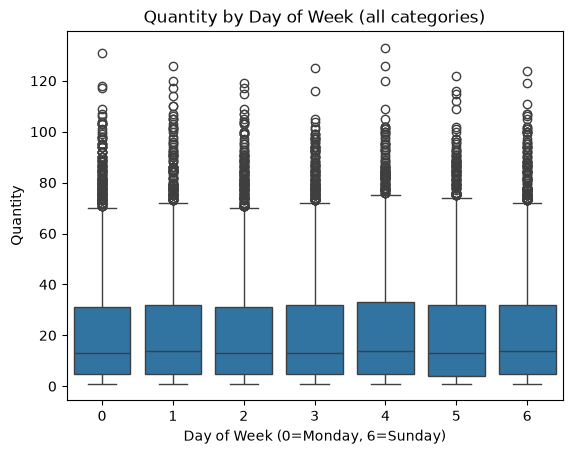

In [11]:
daily['day_of_week'] = daily['order_date'].dt.dayofweek
sns.boxplot(x='day_of_week', y='quantity', data=daily)
plt.title('Quantity by Day of Week (all categories)')
plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
plt.ylabel('Quantity')
plt.show()

In [12]:
daily.to_csv('../data/daily_demand_by_category.csv', index=False)
print("Saved to data/daily_demand_by_category.csv")
print(daily.shape)

Saved to data/daily_demand_by_category.csv
(17151, 7)


In [13]:
import os
print(os.path.exists('../data/daily_demand_by_category.csv'))

True
